In [1]:
from strategy import *
from astropy.coordinates import ICRS
P = load_params('params_strategy.par')
import numpy as np
import matplotlib.pyplot as plt
from astropy.time import Time, TimeDelta
from astropy.coordinates import EarthLocation
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt
from astropy.coordinates import EarthLocation, SkyCoord, AltAz
from astropy.time import Time
import astropy.units as u
from astropy.coordinates import ICRS

P = load_params('local_params_strategy.par')

name=P['name_field']
c=SkyCoord.from_name(name)
ra = 0 
dec = c.dec.value

#load the observer position
lat = P['latitude']

#Load the scan duration and generate the time coordinates with the desired acquisition rate. 
T_duration = P['T_duration'] 
dt = P['dt']*np.pi/3.14 #Make the timestep non rational to avoid some stripes in the hitmap. 
spf = int(1/np.round(dt*3600,3)) #sample per frame defined here as the acquisition rate in Hz. 

HA = np.arange(-T_duration/2, T_duration/2, dt)  # in hours
#LST = np.arange(-T_duration/2,T_duration/2,dt) #hours

T = np.arange(0, T_duration, dt) * 3600  # seconds


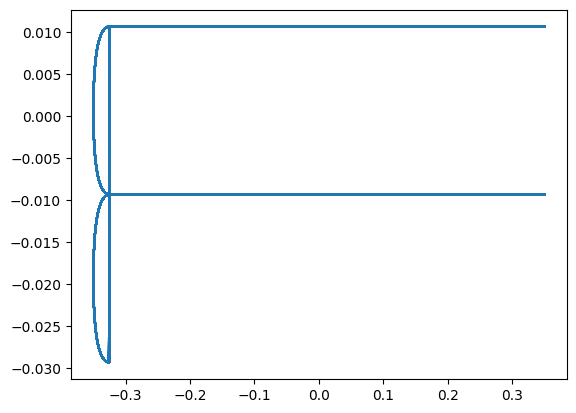

In [2]:
az, alt, flag = genLocalPath_cst_el_scan(az_size=P['az_size'], alt_size=P['alt_size'], alt_step=P['alt_step'], acc=P['acc'], scan_v=P['scan_v'], dt=np.round(dt*3600,3))
scan_path, scan_flag = genScanPath(T, alt, az, flag)
plt.plot(scan_path[:,0],scan_path[:,1] )

In [3]:
#------------------------
# Constants
decr = np.radians(dec)  # DEC offset due to scanning [rad]
latr = np.radians(lat)             # Observer latitude [rad]
#HA = ha.copy() # Hour angle [hour]
HAr = HA * np.pi / 12 # Hour angle [rad]
HAd = np.degrees(HAr) # Hour angle [deg]

# Precompute trigonometric terms
sin_dec = np.sin(decr)
cos_dec = np.cos(decr)
sin_lat = np.sin(latr)
cos_lat = np.cos(latr)
cos_HA = np.cos(HAr)
sin_HA = np.sin(HAr)
#------------------------

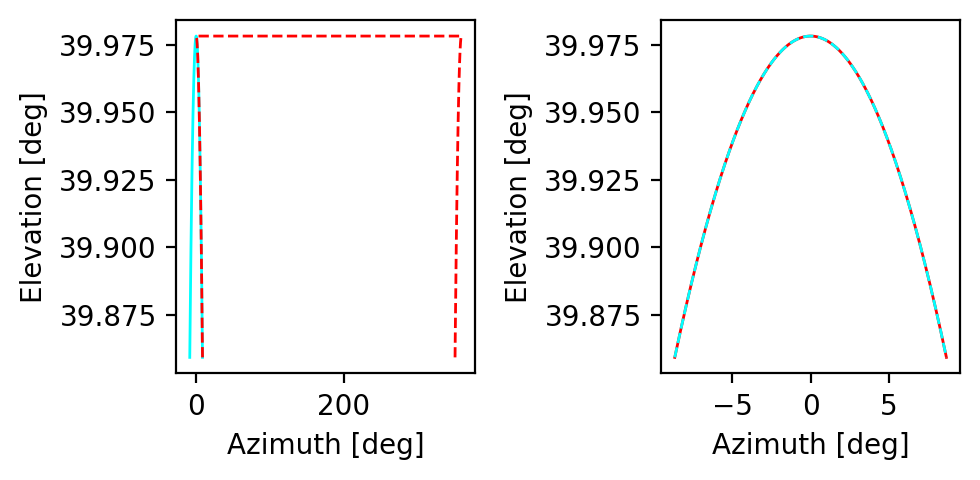

In [4]:
#NAMAP formula
#-------------------
el = np.arcsin(sin_dec*sin_lat+cos_lat*cos_dec*cos_HA) 
az = np.arccos((sin_dec-sin_lat*np.sin(el))/(cos_lat*np.cos(el)))
index, = np.where(sin_HA>0)
az[index] = 2*np.pi - az[index]
#-----------

#Strategy formula
#-----------
cos_za = sin_lat * sin_dec + cos_lat * cos_dec * cos_HA
za = np.arccos(cos_za)
sin_za = np.sin(za)
alti = np.pi/2 - za
cosAz = (sin_dec - sin_lat * cos_za)/(cos_lat * sin_za)
sinAz = sin_HA * cos_dec/ sin_za
azi = np.arctan2(sinAz,cosAz)
#-----------

# "Unwrap" from [0, 2π) to (-π, π]
#---------------------------------------------------
azi_unwrapped = (azi + np.pi) % (2 * np.pi) - np.pi
az_unwrapped  = (az  + np.pi) % (2 * np.pi) - np.pi
#---------------------------------------------------

fig, axs = plt.subplots(1,2,figsize=(5,2.5),dpi=200)
axs[0].plot(np.degrees(azi), np.degrees(alti), c='cyan', lw=1, ls='-')
axs[0].plot(np.degrees(az), np.degrees(el), c='r', lw=1, ls='--')
axs[0].set_xlabel("Azimuth [deg]")
axs[0].set_ylabel("Elevation [deg]")
axs[1].plot(np.degrees(az_unwrapped), np.degrees(el), c='r', lw=1, ls='-')
axs[1].plot(np.degrees(azi_unwrapped),      np.degrees(alti),      c='cyan', lw=1, ls='--')
axs[1].set_xlabel("Azimuth [deg]")
axs[1].set_ylabel("Elevation [deg]")
#---
plt.tight_layout()
plt.show()

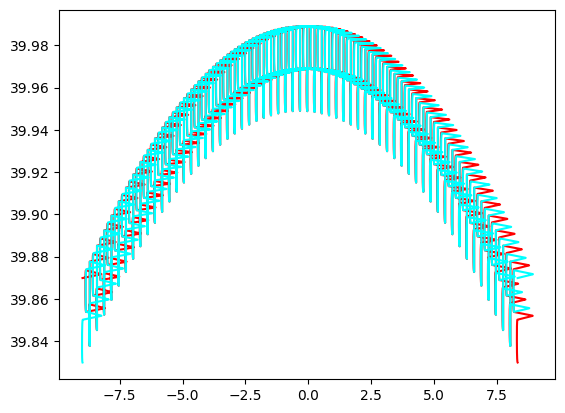

In [5]:
# Apply scan offsets to (az_c, alt_c)
# These are small-angle offsets in azimuth and altitude

#3) Namap formula
el_tot = el + np.radians(scan_path[:, 1])
az_tot = az + np.radians(scan_path[:, 0])
az_tot_unwrapped = (az_tot + np.pi) % (2 * np.pi) - np.pi
plt.plot(np.degrees(az_tot_unwrapped), np.degrees(el_tot), 'r') 


#1) Strategy formula
alti_tot = alti + np.radians(scan_path[:,1])
azi_tot  = azi  + np.radians(scan_path[:,0]) 
azi_unwrapped = (azi_tot + np.pi) % (2 * np.pi) - np.pi
plt.plot(np.degrees(azi_unwrapped),    np.degrees(alti_tot), 'cyan') 


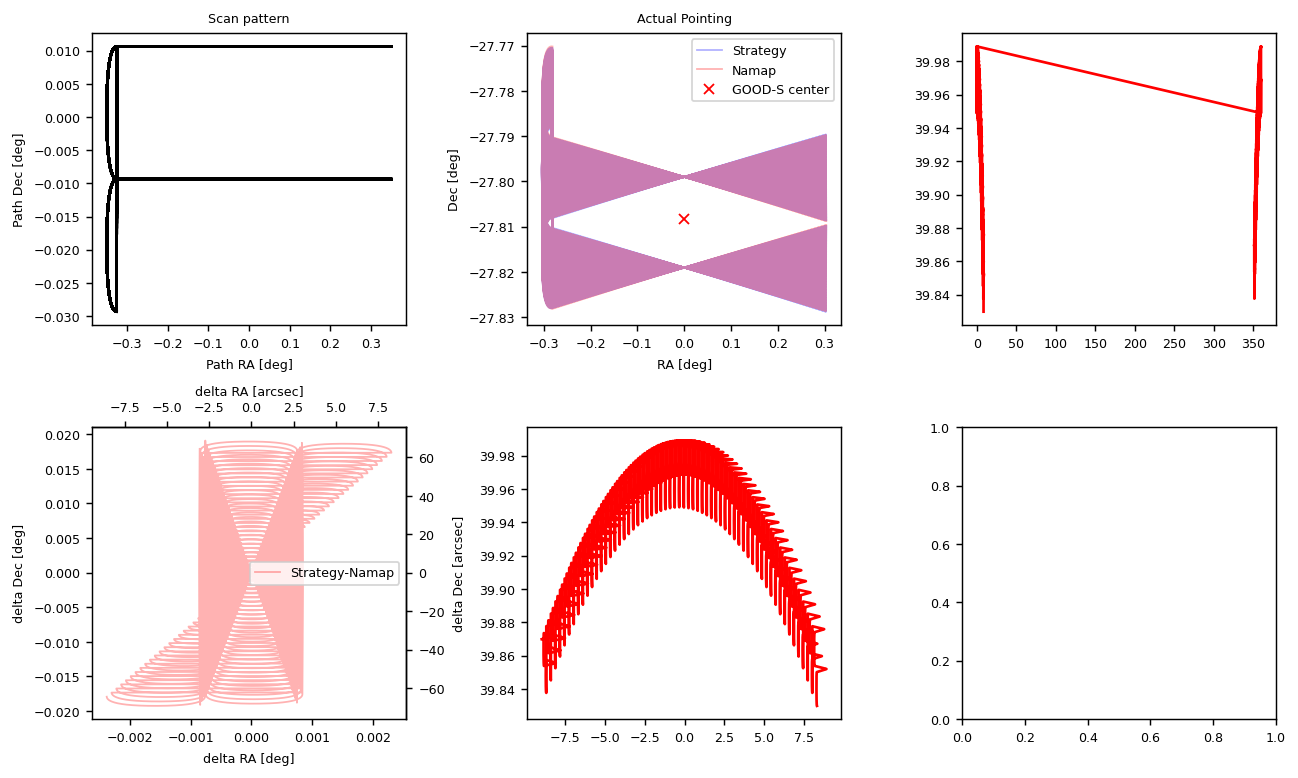

In [6]:

sin_dec_point = np.sin(alti_tot)*sin_lat + np.cos(alti_tot)*cos_lat*np.cos(azi_tot)
dec_point = np.arcsin(sin_dec_point)
cos_HA_point = ( np.sin(alti_tot)- sin_dec_point*sin_lat )/ (np.cos(dec_point)*cos_lat)
ha_point = np.arccos(cos_HA_point)*np.where((azi_tot > 0)&(azi_tot<=np.pi), 1, -1)
path = np.vstack((np.degrees(ha_point-HA*np.pi/12),np.degrees(dec_point))).T
lst = HA
#------------------------------------------------------------------------------
# Function to convert AZ and EL to RA and DEC
sin_el_tot = np.sin(el_tot)
sin_az_tot = np.sin(az_tot)
cos_el_tot = np.cos(el_tot)
cos_az_tot = np.cos(az_tot)

sin_dec_namap = sin_el_tot*sin_lat+cos_lat*cos_el_tot*cos_az_tot
dec_namap = np.arcsin(sin_dec_namap)
cos_dec_namap = np.cos(dec_namap)
hour_angle = np.arccos((sin_el_tot-sin_lat*sin_dec_namap)/(cos_lat*cos_dec_namap))
index, = np.where(sin_az_tot > 0)
hour_angle[index] =  - hour_angle[index]
ra_namap = HA*15 - np.degrees(hour_angle) #self.ha2ra(hour_angle/15.)*15.
index, = np.where(ra_namap<0)
#ra_namap[index]+=360
path_namap = np.vstack((ra_namap,np.degrees(dec_namap))).T

BS=7; plt.rc('font', size=BS); plt.rc('axes', titlesize=BS); plt.rc('axes', labelsize=BS); 
fig, axs = plt.subplots(2,3,figsize=(10,6),dpi=130)

axs[0,0].plot(scan_path[:,0],scan_path[:,1],c='k' )
axs[0,0].set_xlabel('Path RA [deg]');axs[0,0].set_ylabel('Path Dec [deg]')
axs[0,0].set_title('Scan pattern')
axs[0,1].set_title('Actual Pointing')
axs[0,1].plot(path[:,0]+ra, path[:,1], 'b', lw=1, alpha=0.3, label='Strategy')
axs[0,1].plot(path_namap[:,0]+ra, path_namap[:,1], 'r', lw=1, alpha=0.3, label='Namap')
axs[0,1].plot(ra,dec, 'xr', label='GOOD-S center')
axs[0,1].set_xlabel('RA [deg]');axs[0,1].set_ylabel('Dec [deg]')
axs[0,1].legend()
axs[1,0].plot(path[:,0]-path_namap[:,0], path[:,1]-path_namap[:,1], 'r', lw=1, alpha=0.3, label='Strategy-Namap')
axs[1,0].set_xlabel('delta RA [deg]');axs[1,0].set_ylabel('delta Dec [deg]');axs[1,0].legend(loc='center right')
axs[1,1].plot(np.degrees(az_tot_unwrapped), np.degrees(el_tot), 'r') 
axs[0,2].plot(np.degrees(az_tot), np.degrees(el_tot), 'r') 


def F(x): return (x*u.deg).to(u.arcsec).value
secax = axs[1,0].secondary_xaxis("top", functions=(F,F))
secax.set_xlabel('delta RA [arcsec]')
secax = axs[1,0].secondary_yaxis("right", functions=(F,F))
secax.set_ylabel('delta Dec [arcsec]')
plt.tight_layout()

Text(155.13888888888889, 0.5, 'Dec [deg]')

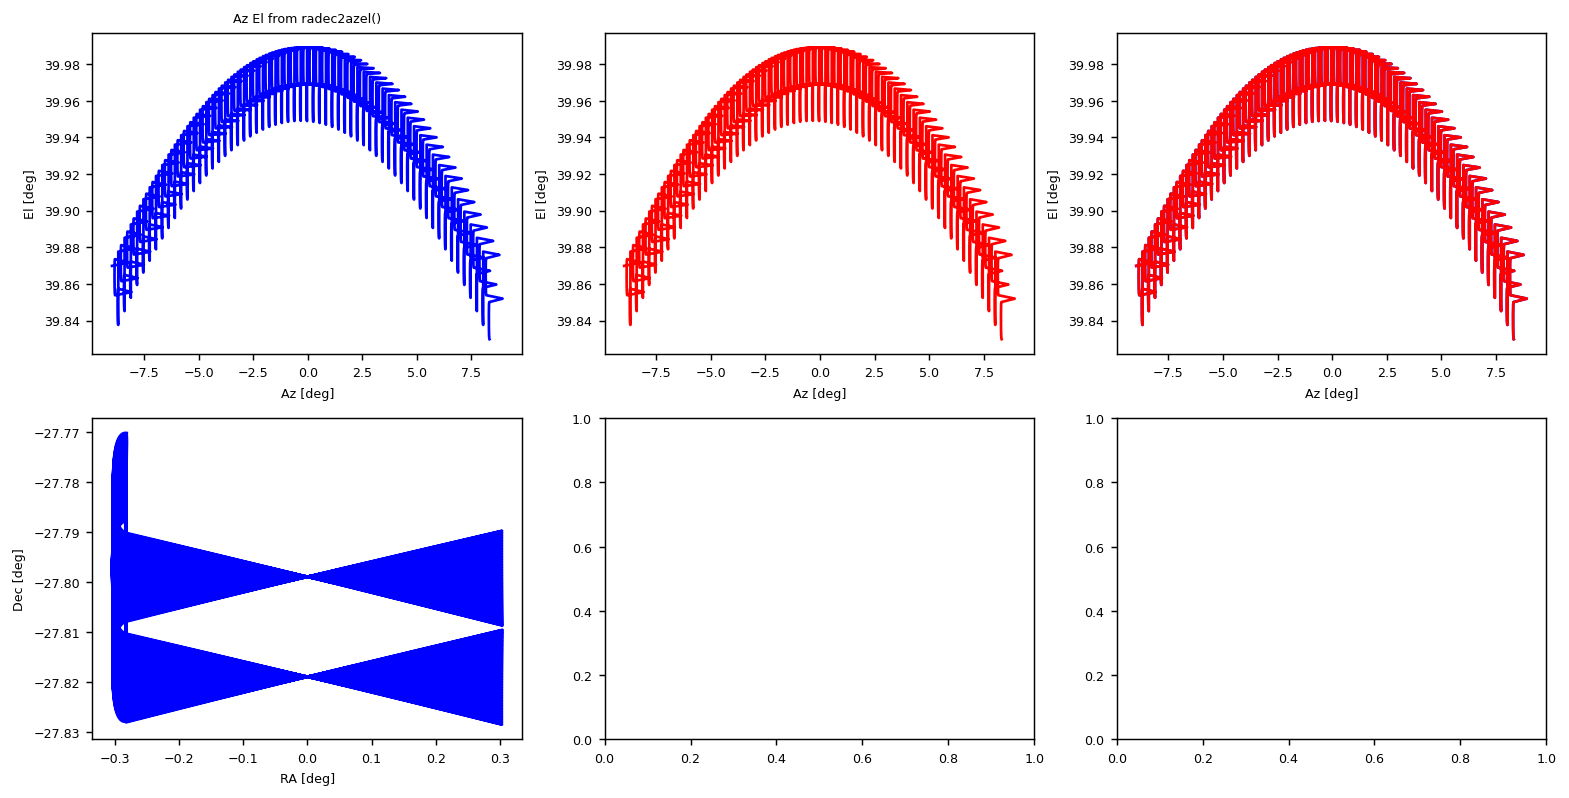

In [7]:
import src.pointing as pt  

conv2azel = pt.utils(ra_namap/15, np.degrees(dec_namap), HA, lat) #hour, deg, hour, deg
az_convert, el_convert = conv2azel.radec2azel()
az_convert_unwrapped = (np.radians(az_convert) + np.pi) % (2 * np.pi) - np.pi


fig, axs = plt.subplots(2,3,figsize=(12,6),dpi=130)
axs[0,0].plot(np.degrees(az_convert_unwrapped),el_convert, c='b')
axs[0,0].set_xlabel('Az [deg]');axs[0,0].set_ylabel('El [deg]')
axs[0,0].set_title('Az El from radec2azel()')
axs[0,1].plot(np.degrees(az_tot_unwrapped), np.degrees(el_tot), 'r') 
axs[0,1].set_xlabel('Az [deg]');axs[0,1].set_ylabel('El [deg]')
axs[0,2].plot(np.degrees(az_convert_unwrapped),el_convert, c='b')
axs[0,2].plot(np.degrees(az_tot_unwrapped), np.degrees(el_tot), 'r') 
axs[0,2].set_xlabel('Az [deg]');axs[0,2].set_ylabel('El [deg]')
fig.tight_layout()

# Function to convert AZ and EL to RA and DEC
sin_el = np.sin(np.radians(el_convert))
sin_az = np.sin(np.radians(az_convert))
cos_el = np.cos(np.radians(el_convert))
cos_az = np.cos(np.radians(az_convert))

sin_dec_namap = sin_el*sin_lat+cos_lat*cos_el*cos_az
dec_namap = np.arcsin(sin_dec_namap)
cos_dec_namap = np.cos(dec_namap)
hour_angle = np.arccos((sin_el-sin_lat*sin_dec_namap)/(cos_lat*cos_dec_namap))
index, = np.where(sin_az > 0)
hour_angle[index] =  - hour_angle[index]
ra_namap = HA*15 - np.degrees(hour_angle) #self.ha2ra(hour_angle/15.)*15.
index, = np.where(ra_namap<0)
#ra_namap[index]+=360
path_namap = np.vstack((ra_namap,np.degrees(dec_namap))).T
axs[1,0].plot(path_namap[:,0], path_namap[:,1], c='b')
axs[1,0].set_xlabel('RA [deg]');axs[1,0].set_ylabel('Dec [deg]')

In [8]:
#Load the timestreams
import astropy.table as tb
file = 'fits_and_hdf5/TOD_pySIDES_from_uchuu_tile_0_1.414deg_x_1.414deg_fir_lines_res20arcsec_dnu4.0GHz_full_de_Looze_smoothed_MJy_sr.hdf5' 
import src.mapmaker as mp
ctype = 'RA and DEC'
crpix = np.asarray([126, 127])
cdelt = np.asarray([0.0055555555555556, 0.0055555555555556]) 
crval =  np.asarray([0, -27.80833 ]) 
pixnum = np.asarray([100., 100.]) 
H = h5py.File(file, "a")
f = H[f'RA']
RA_strategy_original = f['data'][()]
f = H[f'DEC']
DEC_strategy_original = f['data'][()]
H.close()

btable = tb.Table.read('config/TIM_kid_table.tsv' , format='ascii.tab')
filtered = btable[btable['Frequency'] == 715]
kid_num = filtered['Name'] #(filtered['Name'][0],)
pixel_offset_HW, pixel_shift_HW = filtered['EL'], filtered['XEL']


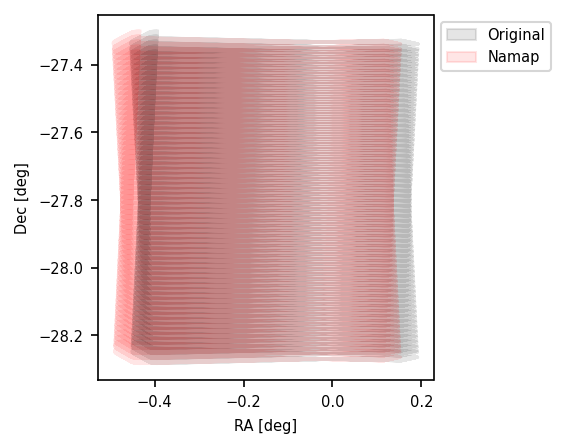

In [38]:
'''
import src.quaternion as quat
pixel_offset_HW, pixel_shift_HW = pixelOffset(P['nb_pixel_HW'], 0,0)
xEL = np.degrees(np.radians(az_convert)*np.cos(np.radians(el_convert)))
xEL_unwrapped = (np.radians(xEL) + np.pi) % (2 * np.pi) - np.pi
plt.plot(np.degrees(xEL_unwrapped), el_convert, 'k'); plt.xlabel('xEL [deg]'); plt.ylabel('El [deg]')
#xEL =np.degrees(xEL_unwrapped)
ra_corrected = np.zeros((len(pixel_offset_HW), len(az_convert)))
dec_corrected = np.zeros((len(pixel_offset_HW), len(az_convert)))
xEL = np.degrees(np.radians(az_convert)*np.cos(np.radians(el_convert)))
'''
import src.quaternion as quat

ra_corrected = []
dec_corrected = []

ra_original= []
dec_original= []
data = []

import src.quaternion as quat
xEL = np.degrees(np.radians(az_convert)*np.cos(np.radians(el_convert)))
xel_unwrapped = (xEL+ np.pi) % (2 * np.pi) - np.pi

BS=7; plt.rc('font', size=BS); plt.rc('axes', titlesize=BS); plt.rc('axes', labelsize=BS); 
fig, axs = plt.subplots(figsize=(3,3),dpi=150)

for i, name in enumerate(kid_num):
    
    #------------------------------------------------------------------------------------
    EL_corrected_temp = el_convert + pixel_offset_HW[i]
    xEL_corrected_temp = xEL + pixel_shift_HW[i]
    AZ_corrected_temp =  az_convert + np.degrees(np.radians(pixel_shift_HW[i])/ np.cos(np.radians(el_convert))) #np.degrees(np.radians(xEL_corrected_temp)/np.cos(np.radians(el_convert)))

    # Function to convert AZ and EL to RA and DEC
    sin_el = np.sin(np.radians(EL_corrected_temp))
    sin_az = np.sin(np.radians(AZ_corrected_temp))
    cos_el = np.cos(np.radians(EL_corrected_temp))
    cos_az = np.cos(np.radians(AZ_corrected_temp))
    sin_dec_namap = sin_el*sin_lat+cos_lat*cos_el*cos_az
    dec_namap = np.arcsin(sin_dec_namap)
    cos_dec_namap = np.cos(dec_namap)
    hour_angle = np.arccos((sin_el-sin_lat*sin_dec_namap)/(cos_lat*cos_dec_namap))
    index, = np.where(sin_az > 0)
    hour_angle[index] =  - hour_angle[index]
    ra_namap = HA*15 - np.degrees(hour_angle) #self.ha2ra(hour_angle/15.)*15.
    #ra_namap[index]+=360
    path = np.vstack((ra_namap,np.degrees(dec_namap))).T
    #plt.plot(path[:,0], path[:,1], )
    axs.set_xlabel('RA [deg]');axs.set_ylabel('Dec [deg]')
    ra_corrected.append(ra_namap)
    dec_corrected.append(np.degrees(dec_namap))
    #-------------------------------------------------------------------------------------

    H = h5py.File(file, "a")
    f = H[f'kid_{name}_roach']
    data.append(f['data'][()])
    f = H[f'kid_{name}_RA']
    ra_original.append(f['data'][()])
    f = H[f'kid_{name}_DEC']
    dec_original.append(f['data'][()])
    H.close()

    axs.plot(ra_original[i], dec_original[i], 'k', alpha=0.1)

    #plt.plot(ra_original[i], np.degrees(dec_namap), 'b', alpha=0.1)
    #plt.plot(ra_namap-ra_original[i],  np.ones(len(ra_namap))*pixel_offset_HW[i], 'r', alpha=0.1)
    axs.plot(ra_namap, dec_original[i], 'r', alpha=0.1)

#plt.plot(path_namap[:,0], path_namap[:,1], 'k')
#plt.plot(RA_strategy_original, DEC_strategy_original, 'cyan', alpha=0.1, ls=':', lw=0.1)
patchs =[]
patch = mpatches.Patch(color='k', label= 'Original', alpha=0.1); patchs.append(patch); 
patch = mpatches.Patch(color='r', label= 'Namap', alpha=0.1); patchs.append(patch); 
fig.tight_layout()
axs.legend(handles=patchs, bbox_to_anchor=(1,1))
parallactic = np.zeros_like(np.asarray(ra_corrected)) 


/home/mvancuyck/Desktop/TIM_analysis/namap/src/mapmaker.py:334: RuntimeWarning: invalid value encountered in divide
  hist /= norm


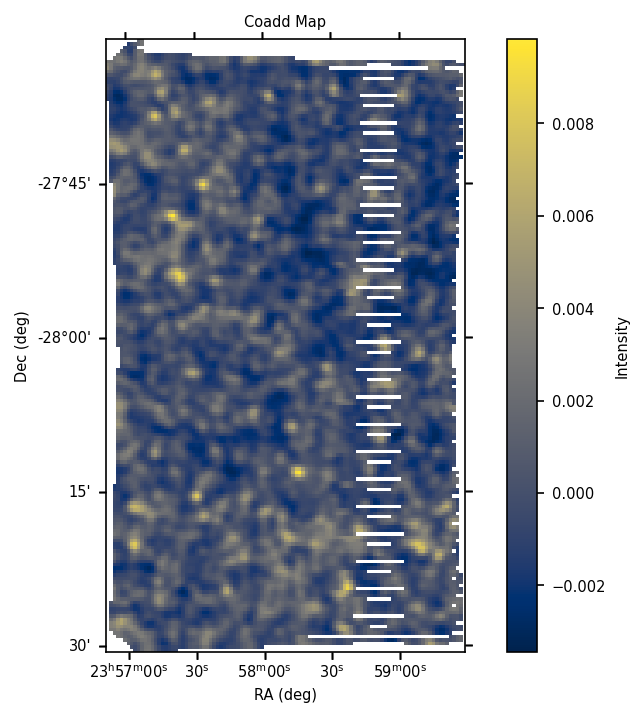

In [39]:
maps = mp.maps(ctype, crpix, cdelt, crval, pixnum, data, ra_corrected, dec_corrected, False, 0, 
                coadd=True, noise=np.ones(len(kid_num)), telcoord = False, parang=parallactic)
maps.wcs_proj()
map_values = maps.map2d()
maps.map_plot(data_maps = map_values, kid_num=kid_num)
plt.show()


/home/mvancuyck/Desktop/TIM_analysis/namap/src/mapmaker.py:334: RuntimeWarning: invalid value encountered in divide
  hist /= norm


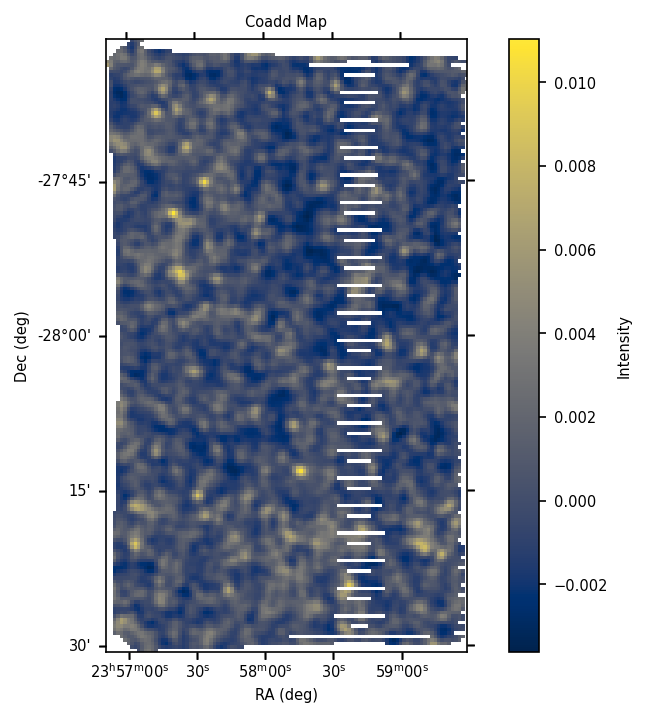

In [30]:
maps = mp.maps(ctype, crpix, cdelt, crval, pixnum, data, ra_original, dec_corrected, False, 0, 
                coadd=True, noise=np.ones(len(kid_num)), telcoord = False, parang=parallactic)
maps.wcs_proj()
map_values = maps.map2d()
maps.map_plot(data_maps = map_values, kid_num=kid_num)
plt.show()